# AutoCloud-Agent: Multi-Day Generalization Evaluation

**Run on Kaggle — requires the same 3 datasets as train_rl_agents.ipynb**

### What this notebook does
The RL agent was trained on **Day 1** of the Alibaba trace.  
This notebook evaluates all 8 methods across **every available day** of the trace  
to test how well the agent generalizes to unseen workload patterns.

### Setup
1. Add `autocloud-agent-code` dataset
2. Add `autocloud-forecaster-output` dataset (contains `forecaster_weights.pt`, `day1_processed.npy`, `day2_processed.npy`)
3. Add `autocloud-rl-output` dataset (contains checkpoints)
4. Add `rohitdurbha/alibaba-cluster-data` dataset

### Output
- Per-day metric table for all 8 methods
- Line plots showing performance vs day index
- Summary: mean ± std across all days

In [6]:
# Cell 1: Paths and dependencies
import os, sys, glob, json
import numpy as np
import matplotlib.pyplot as plt

# ── Input datasets ───────────────────────────────────────────────────────────
_candidates = [
    '/kaggle/input/alibaba-cluster-data',
    '/kaggle/input/datasets/rohitdurbha/alibaba-cluster-data',
]
ALIBABA_INPUT = next((p for p in _candidates if os.path.isdir(p)), None)
if ALIBABA_INPUT is None:
    hits = glob.glob('/kaggle/input/**/machine_usage*.csv', recursive=True)
    if hits:
        ALIBABA_INPUT = os.path.dirname(sorted(hits, key=os.path.getsize, reverse=True)[0])

FORECAST_INPUT  = '/kaggle/input/datasets/chaitanya2277/train-forecaster/train_Forecaster'
RL_INPUT        = '/kaggle/input/datasets/chaitanya2277/rl-agents-output'
CHECKPOINT_DIR  = os.path.join(RL_INPUT, 'rl_agents')
WORK_DIR        = '/kaggle/working'

def _find_project_dir():
    for candidate in [
        '/kaggle/input/autocloud-agent-code/autocloud_agent',
        '/kaggle/input/datasets/chaitanya2277/autocloud-agent-v2',
        '/kaggle/input/autocloud-agent-code',
    ]:
        if os.path.isdir(os.path.join(candidate, 'environment')):
            return candidate
    hits = glob.glob('/kaggle/input/**/environment/workload.py', recursive=True)
    if hits:
        return os.path.dirname(os.path.dirname(hits[0]))
    return None

PROJECT_DIR = _find_project_dir()
sys.path.insert(0, PROJECT_DIR)

!pip install simpy gymnasium --quiet

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f'PROJECT_DIR   : {PROJECT_DIR}')
print(f'ALIBABA_INPUT : {ALIBABA_INPUT}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR}')
print(f'Checkpoints   : {os.listdir(CHECKPOINT_DIR) if os.path.exists(CHECKPOINT_DIR) else "NOT FOUND"}')

PROJECT_DIR   : /kaggle/input/datasets/chaitanya2277/autocloud-agent-v2/autocloud_agent
ALIBABA_INPUT : /kaggle/input/datasets/rohitdurbha/alibaba-cluster-data
CHECKPOINT_DIR: /kaggle/input/datasets/chaitanya2277/rl-agents-output/rl_agents
Checkpoints   : ['training_metrics.json', 'so_critic_final.pt', 'training_curves.png', 'so_actor_final.pt', 'con_critic_final.pt', 'con_actor_final.pt', 'sch_critic_final.pt', 'sch_actor_final.pt']


In [9]:
# Cell 1b: Patch AlibabaTraceLoader with get_full_data / get_train_data
# (needed when the Kaggle code dataset predates these methods)
import types
from environment.workload import AlibabaTraceLoader

def _get_full_data(self):
    if self._workload_bins is None:
        raise RuntimeError("Call .load() before accessing data.")
    return self._workload_bins

def _get_train_data(self):
    if self._workload_bins is None:
        raise RuntimeError("Call .load() before accessing data.")
    bins_per_day = int(self.day_duration_s / self.bin_size_s)
    full = self._workload_bins
    return full[:-bins_per_day] if len(full) > bins_per_day else full

AlibabaTraceLoader.get_full_data  = _get_full_data
AlibabaTraceLoader.get_train_data = _get_train_data
print("AlibabaTraceLoader patched — get_full_data / get_train_data available.")

AlibabaTraceLoader patched — get_full_data / get_train_data available.


In [10]:
# Cell 2: Load full Alibaba trace and split into individual days
from environment.workload import AlibabaTraceLoader

loader = AlibabaTraceLoader(
    data_dir=ALIBABA_INPUT,
    n_machines=5000,   # use all machines
    bin_size_s=30,
)
loader.load(verbose=True, chunk_size=500_000)

full_data    = loader.get_full_data()   # (N_total_bins, 4)
bins_per_day = int(86400 / 30)          # 2880 bins per day
n_days_total = len(full_data) // bins_per_day

print(f'\nFull trace: {len(full_data)} bins = {n_days_total} complete days')

# Split into day arrays
days = []
for d in range(n_days_total):
    day_data = full_data[d * bins_per_day : (d + 1) * bins_per_day]
    days.append(day_data)
    print(f'  Day {d+1}: {len(day_data)} bins  '
          f'mean_cpu={day_data[:,0].mean():.3f}  std={day_data[:,0].std():.3f}')

print(f'\nAgent was trained on Day 1 workload.')
print(f'Evaluating generalization across all {n_days_total} days.')

Found: machine_usage_bigger.csv  (3702 MB)
Large file (3702 MB) — using chunked 2-pass loading ...
  Pass 1/2: computing per-machine CPU variance ...
  4023 total machines; keeping top 4023
  Pass 2/2: reading selected machines ...
Trace spans 192.0 h, 4023 unique machines, 94,999,998 rows
Selected 4023 machines with highest CPU variance
Day 1: 2880 bins, mean CPU=0.333
Day 2: 2880 bins, mean CPU=0.374

Full trace: 22415 bins = 7 complete days
  Day 1: 2880 bins  mean_cpu=0.333  std=0.082
  Day 2: 2880 bins  mean_cpu=0.374  std=0.086
  Day 3: 2880 bins  mean_cpu=0.388  std=0.098
  Day 4: 2880 bins  mean_cpu=0.383  std=0.090
  Day 5: 2880 bins  mean_cpu=0.382  std=0.112
  Day 6: 2880 bins  mean_cpu=0.352  std=0.100
  Day 7: 2880 bins  mean_cpu=0.398  std=0.094

Agent was trained on Day 1 workload.
Evaluating generalization across all 7 days.


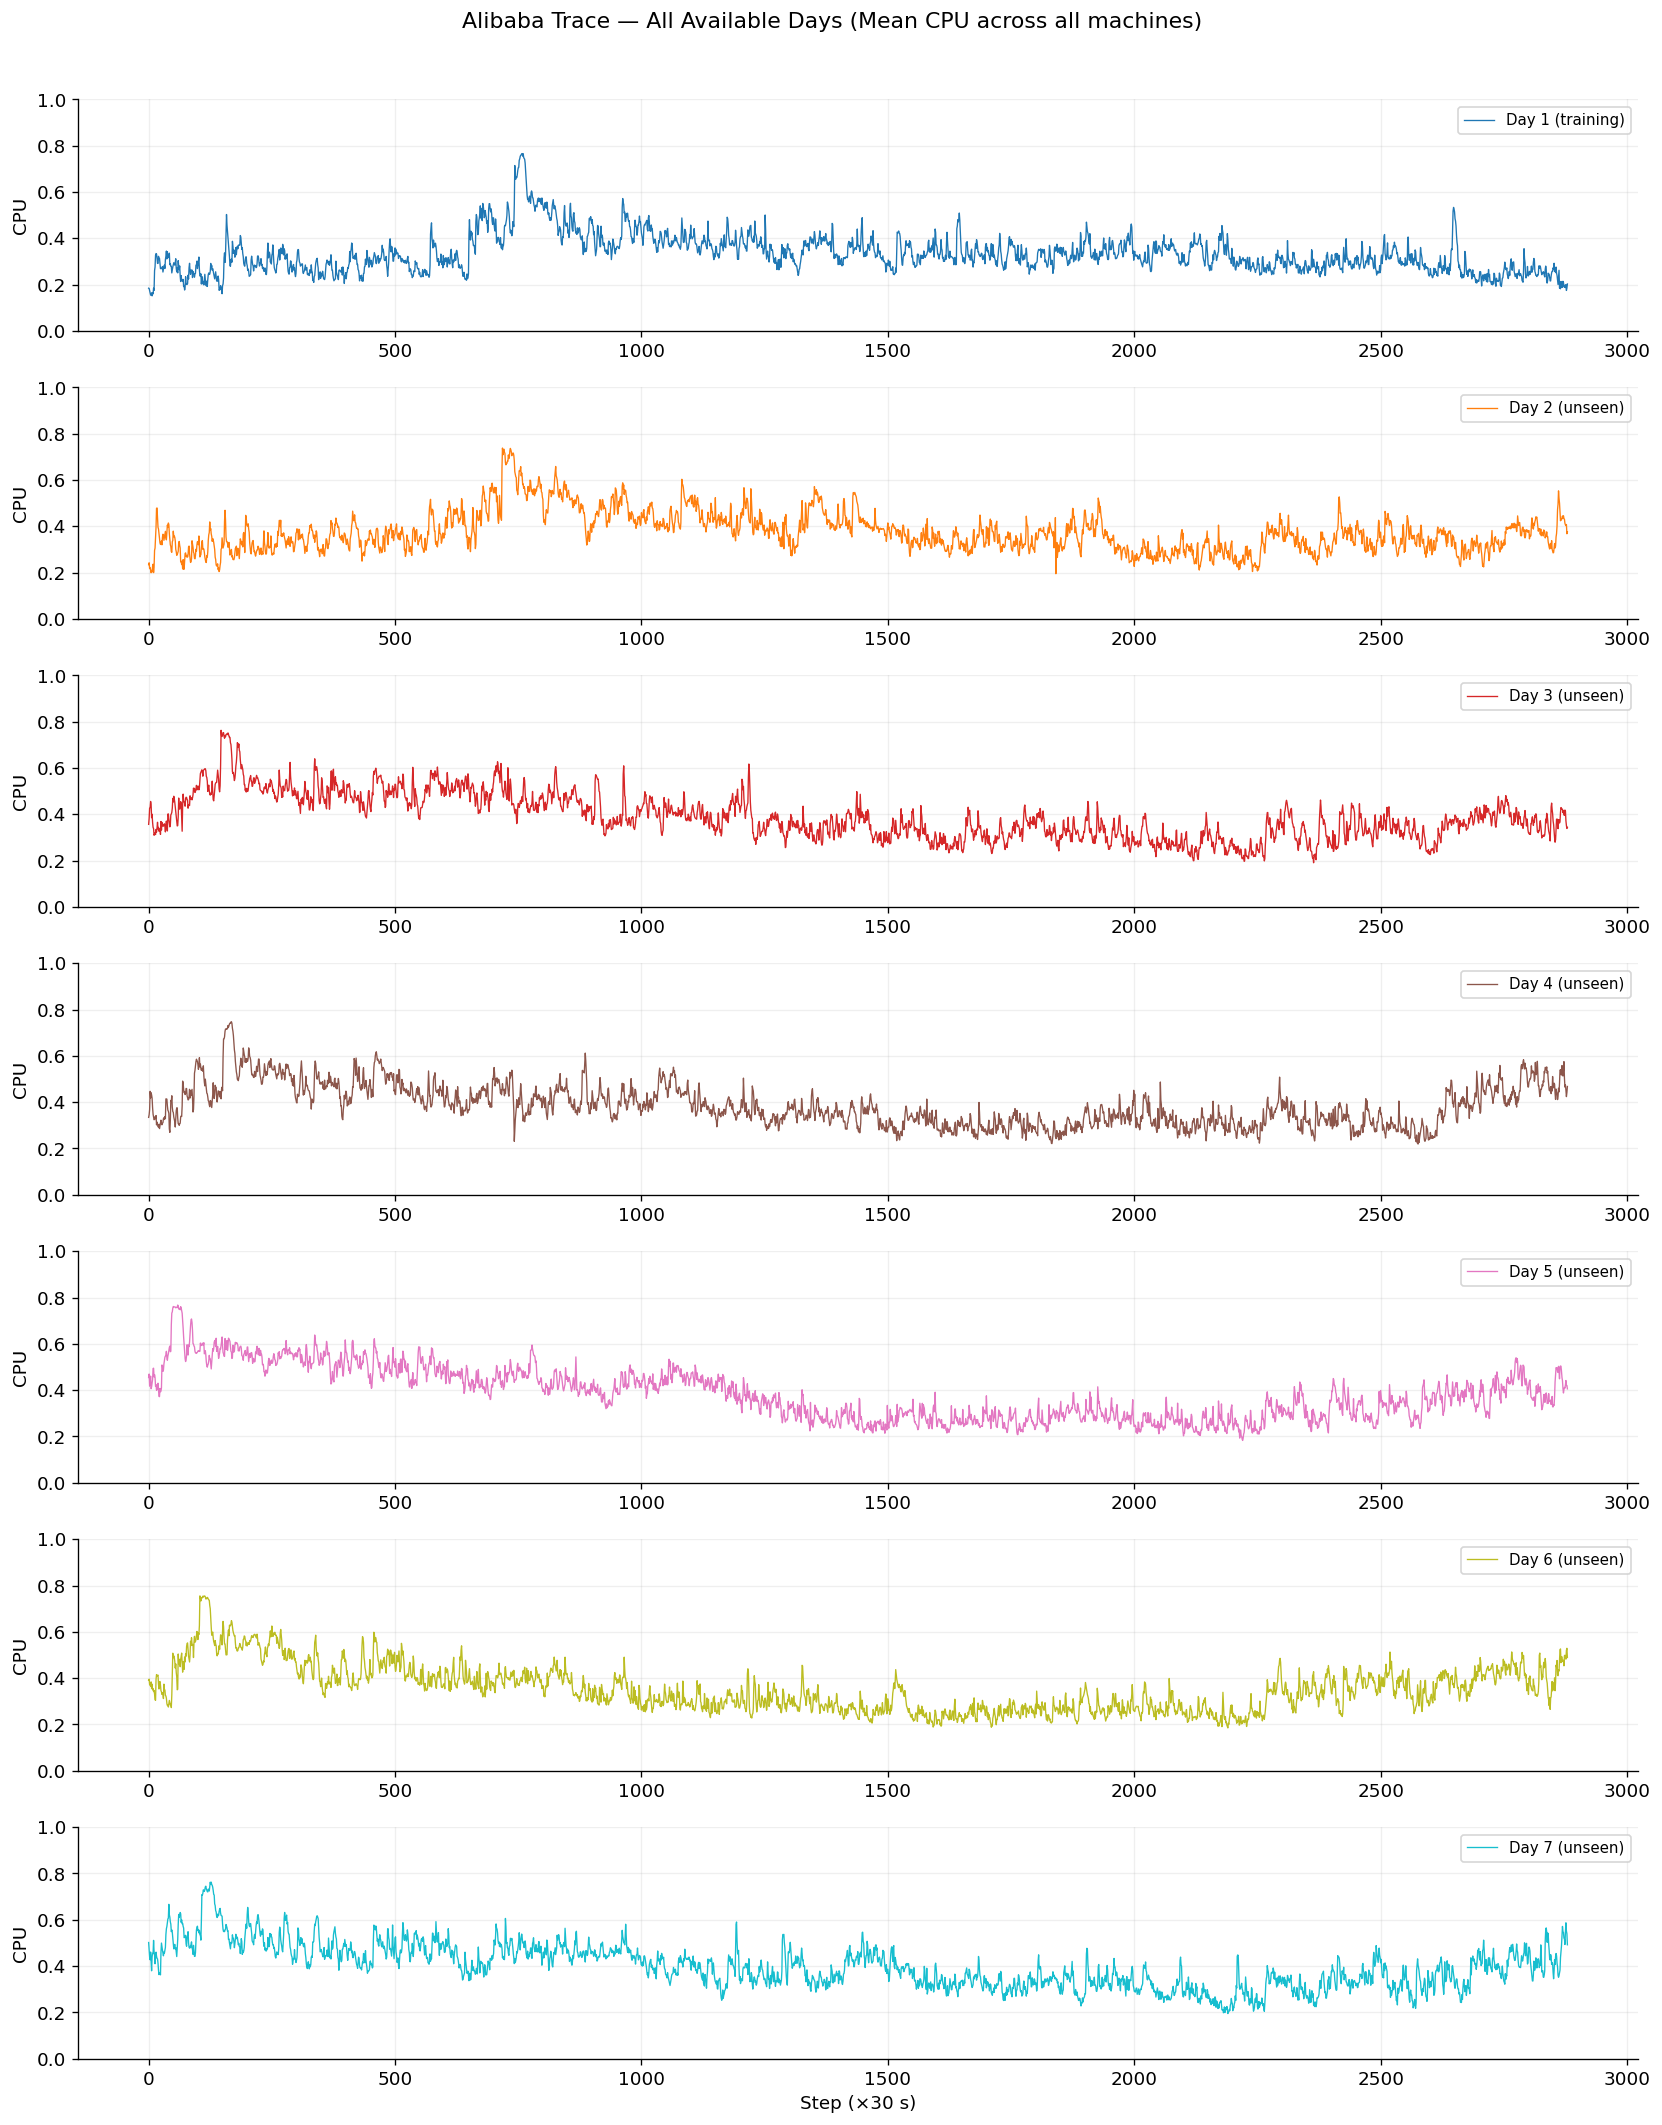

In [11]:
# Cell 3: Visualise all days
fig, axes = plt.subplots(n_days_total, 1, figsize=(14, 2.5 * n_days_total), sharex=False)
if n_days_total == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, n_days_total))
for i, (day_data, ax) in enumerate(zip(days, axes)):
    label = f'Day {i+1}' + (' (training)' if i == 0 else ' (unseen)')
    ax.plot(day_data[:, 0], color=colors[i], lw=0.8, label=label)
    ax.set_ylim(0, 1)
    ax.set_ylabel('CPU')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Step (×30 s)')
plt.suptitle('Alibaba Trace — All Available Days (Mean CPU across all machines)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'all_days_trace.png'), dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# Cell 4: Apply the same workload patch as train_rl_agents.ipynb
import numpy as np
import types
from forecaster.mc_dropout import MCDropoutForecaster

clean_original_predict = MCDropoutForecaster.predict

def safe_patched_predict(self, obs, **kwargs):
    if isinstance(obs, np.ndarray) and obs.size >= 80:
        seq = obs[-80:].reshape(1, 20, 4)
    else:
        seq = obs
    if hasattr(seq, 'cpu'):
        seq = seq.cpu().numpy()
    seq = np.array(seq, dtype=np.float32)
    if seq.ndim == 2:
        seq = np.expand_dims(seq, axis=0)
    return clean_original_predict(self, seq, **kwargs)

MCDropoutForecaster.predict = safe_patched_predict
print('Forecaster patch applied.')

Forecaster patch applied.


In [13]:
# Cell 5: Build workload_fn for each day and run evaluation
from configs.default_config import DEFAULT_CONFIG
from evaluation.evaluator import Evaluator

config = DEFAULT_CONFIG

def make_workload_fn(day_data: np.ndarray):
    rates   = np.clip(day_data[:, 0], 0.1, 1.0)
    n_steps = len(rates)
    def fn(sim_time_seconds: float) -> float:
        return float(rates[int(sim_time_seconds / 30.0) % n_steps])
    return fn

all_day_results = {}   # day_idx -> evaluator results dict

for day_idx, day_data in enumerate(days):
    print(f'\n══ Day {day_idx+1}/{n_days_total} '
          f'(mean_cpu={day_data[:,0].mean():.3f}) ══')

    wfn = make_workload_fn(day_data)

    evaluator = Evaluator(
        config=config,
        checkpoint_dir=CHECKPOINT_DIR,
        n_episodes=5,      # 5 episodes per day to keep runtime manageable
        seeds=[0, 1, 2],
        verbose=True,
        workload_fn=wfn,
    )
    results = evaluator.evaluate_all()
    all_day_results[day_idx + 1] = results

# Save
out_path = os.path.join(WORK_DIR, 'multiday_results.json')
with open(out_path, 'w') as f:
    json.dump(all_day_results, f, indent=2)
print(f'\nSaved: {out_path}')


══ Day 1/7 (mean_cpu=0.333) ══

[Eval] AutoCloud-Agent ...
  seed=0 ... SLA=100.00% cost_eff=0.962
  seed=1 ... SLA=100.00% cost_eff=0.962
  seed=2 ... SLA=100.00% cost_eff=0.962

[Eval] KubernetesHPA ...
  seed=0 ... SLA=100.00% cost_eff=0.937
  seed=1 ... SLA=100.00% cost_eff=0.933
  seed=2 ... SLA=100.00% cost_eff=0.933

[Eval] PIController ...
  seed=0 ... SLA=100.00% cost_eff=0.962
  seed=1 ... SLA=100.00% cost_eff=0.961
  seed=2 ... SLA=100.00% cost_eff=0.956

[Eval] ARIMAPredictive ...
  seed=0 ... SLA=100.00% cost_eff=0.958
  seed=1 ... SLA=100.00% cost_eff=0.958
  seed=2 ... SLA=100.00% cost_eff=0.960

[Eval] SingleAgentPPO ...
  seed=0 ... SLA=100.00% cost_eff=0.924
  seed=1 ... SLA=100.00% cost_eff=0.925
  seed=2 ... SLA=100.00% cost_eff=0.924

[Eval] ThresholdReactive ...
  seed=0 ... SLA=100.00% cost_eff=0.960
  seed=1 ... SLA=100.00% cost_eff=0.960
  seed=2 ... SLA=100.00% cost_eff=0.957

[Eval] ThresholdPredictive ...
  seed=0 ... SLA=100.00% cost_eff=0.961
  seed=1 ...

In [15]:
# Cell 6: Per-day results table
methods      = list(next(iter(all_day_results.values())).keys())
metrics_keys = ['sla_rate', 'cost_efficiency', 'mean_cpu_util', 'node_stability']

for metric in metrics_keys:
    print(f'\n── {metric} ──')
    header = f'{"Day":<6}' + ''.join(f'{m:<22}' for m in methods)
    print(header)
    print('-' * len(header))
    for day_idx in sorted(all_day_results.keys()):
        row = f'{day_idx:<6}'
        for method in methods:
            val = all_day_results[day_idx][method]['mean'][metric]
            std = all_day_results[day_idx][method]['std'][metric]
            cell = f'{val:.1%}±{std:.1%}' if metric == 'sla_rate' else f'{val:.3f}±{std:.3f}'
            row += f'{cell:<22}'
        print(row)


── sla_rate ──
Day   AutoCloud-Agent       KubernetesHPA         PIController          ARIMAPredictive       SingleAgentPPO        ThresholdReactive     ThresholdPredictive   StaticN               
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           
2     100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           
3     100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           100.0%±0.0%           
4     100.0%±0.0%           100.0%±0.0%           100.0%±0.0%        

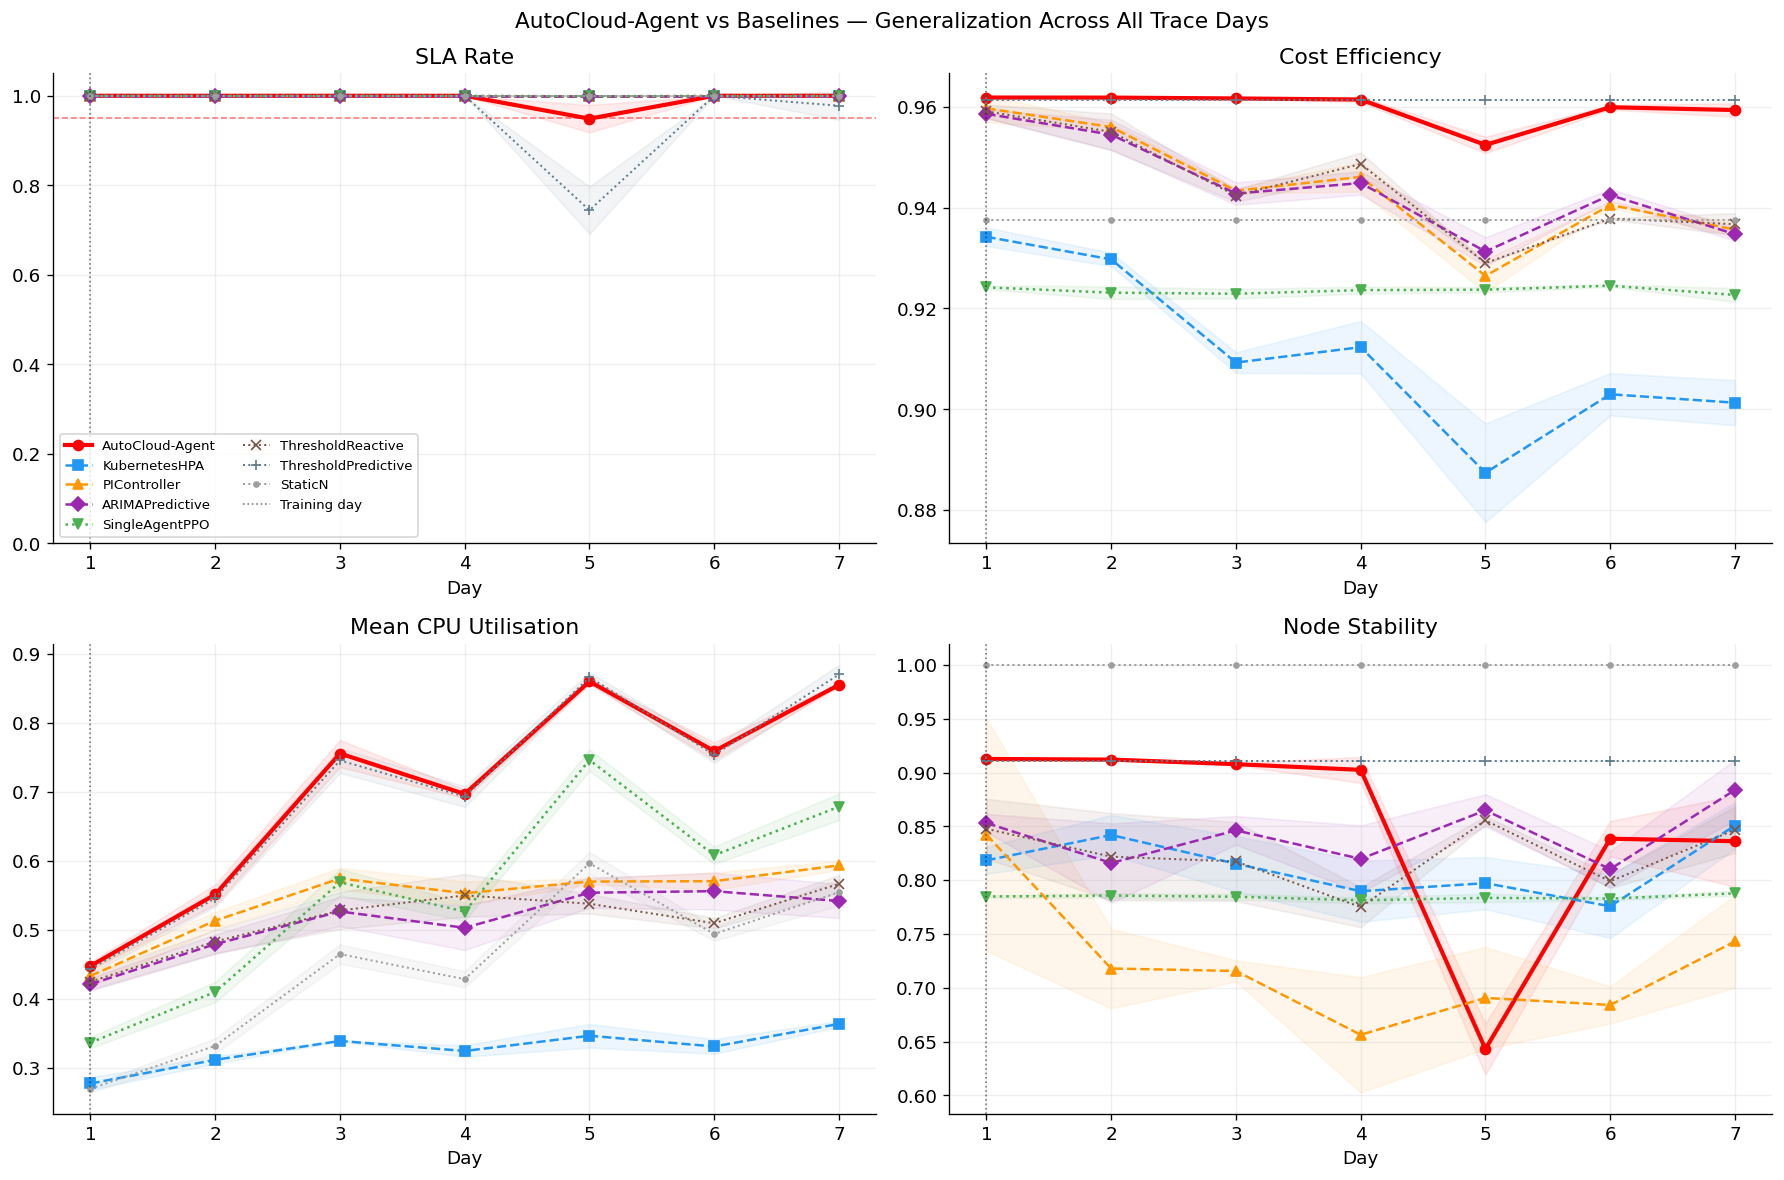

In [16]:
# Cell 7: Line plots — performance vs day for each metric
day_indices = sorted(all_day_results.keys())

method_styles = {
    'AutoCloud-Agent':   ('red',     2.5,  'o',  '-'),
    'KubernetesHPA':     ('#2196F3', 1.5,  's',  '--'),
    'PIController':      ('#FF9800', 1.5,  '^',  '--'),
    'ARIMAPredictive':   ('#9C27B0', 1.5,  'D',  '--'),
    'SingleAgentPPO':    ('#4CAF50', 1.5,  'v',  ':'),
    'ThresholdReactive': ('#795548', 1.2,  'x',  ':'),
    'ThresholdPredictive':('#607D8B',1.2,  '+',  ':'),
    'StaticN':           ('#9E9E9E', 1.2,  '.',  ':'),
}
metric_labels = {
    'sla_rate':        'SLA Rate',
    'cost_efficiency': 'Cost Efficiency',
    'mean_cpu_util':   'Mean CPU Utilisation',
    'node_stability':  'Node Stability',
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, metric in enumerate(metrics_keys):
    ax = axes[ax_idx]
    for method in methods:
        color, lw, marker, ls = method_styles.get(method, ('grey', 1, 'o', '-'))
        vals = [all_day_results[d][method]['mean'][metric] for d in day_indices]
        stds = [all_day_results[d][method]['std'][metric]  for d in day_indices]
        ax.plot(day_indices, vals, color=color, lw=lw, marker=marker,
                ls=ls, markersize=6, label=method)
        ax.fill_between(day_indices,
                        [v-s for v,s in zip(vals,stds)],
                        [v+s for v,s in zip(vals,stds)],
                        alpha=0.08, color=color)
    ax.axvline(x=1, color='black', ls=':', lw=1, alpha=0.5, label='Training day')
    ax.set_title(metric_labels[metric])
    ax.set_xlabel('Day')
    ax.set_xticks(day_indices)
    ax.grid(True, alpha=0.2)
    if metric == 'sla_rate':
        ax.set_ylim(0, 1.05)
        ax.axhline(0.95, color='red', ls='--', lw=1, alpha=0.5)

axes[0].legend(loc='lower left', fontsize=8, ncol=2)
plt.suptitle('AutoCloud-Agent vs Baselines — Generalization Across All Trace Days', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'multiday_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Cell 8: Aggregate summary — mean ± std across ALL days
print('=== Aggregate Performance Across All Days ===')
print(f'(mean ± std over {n_days_total} days × 5 episodes × 3 seeds)')
print()
print(f'{"Method":<22} {"SLA Rate":<18} {"Cost Eff":<18} {"CPU Util":<18} {"Stability":<18}')
print('-' * 94)

for method in methods:
    agg = {k: [] for k in metrics_keys}
    for day_idx in day_indices:
        for k in metrics_keys:
            agg[k].append(all_day_results[day_idx][method]['mean'][k])

    row = f'{method:<22}'
    for k in metrics_keys:
        mu  = np.mean(agg[k])
        std = np.std(agg[k])
        row += f'{mu:.1%}±{std:.1%}  ' if k == 'sla_rate' else f'{mu:.3f}±{std:.3f}  '
    print(row)

print()
print('Note: higher std across days = more sensitive to workload distribution shift.')
print('AutoCloud-Agent std should be low — it was trained with seed randomization.')

=== Aggregate Performance Across All Days ===
(mean ± std over 7 days × 5 episodes × 3 seeds)

Method                 SLA Rate           Cost Eff           CPU Util           Stability         
----------------------------------------------------------------------------------------------
AutoCloud-Agent       99.3%±1.8%  0.960±0.003  0.704±0.142  0.850±0.090  
KubernetesHPA         100.0%±0.0%  0.911±0.015  0.328±0.026  0.813±0.025  
PIController          100.0%±0.0%  0.944±0.011  0.544±0.051  0.721±0.056  
ARIMAPredictive       100.0%±0.0%  0.944±0.009  0.512±0.045  0.842±0.026  
SingleAgentPPO        100.0%±0.0%  0.924±0.001  0.554±0.133  0.784±0.002  
ThresholdReactive     100.0%±0.0%  0.944±0.010  0.515±0.044  0.823±0.027  
ThresholdPredictive   96.0%±8.8%  0.961±0.000  0.703±0.147  0.910±0.000  
StaticN               100.0%±0.0%  0.938±0.000  0.449±0.108  1.000±0.000  

Note: higher std across days = more sensitive to workload distribution shift.
AutoCloud-Agent std should be low 

In [19]:
# Cell 9: Rank AutoCloud-Agent against baselines per day
print('=== AutoCloud-Agent Rank per Day (1 = best) ===')
print(f'{"Day":<6} {"SLA":<8} {"CostEff":<10} {"CPUUtil":<10} {"Stability":<12} Overall')
print('-' * 58)

overall_ranks = []
for day_idx in day_indices:
    day_res = all_day_results[day_idx]
    ranks = {}
    for metric in metrics_keys:
        scores = [(m, day_res[m]['mean'][metric]) for m in methods]
        scores.sort(key=lambda x: x[1], reverse=True)
        ranks[metric] = next(i+1 for i,(m,_) in enumerate(scores) if m == 'AutoCloud-Agent')
    avg_rank = np.mean(list(ranks.values()))
    overall_ranks.append(avg_rank)
    label = '← training day' if day_idx == 1 else ''
    print(f'{day_idx:<6} {ranks["sla_rate"]:<8} {ranks["cost_efficiency"]:<10} '
          f'{ranks["mean_cpu_util"]:<10} {ranks["node_stability"]:<12} '
          f'{avg_rank:.1f}  {label}')

print(f'\nMean overall rank across all days: {np.mean(overall_ranks):.2f} / {len(methods)}')
print(f'(Rank 1 = best method)')

=== AutoCloud-Agent Rank per Day (1 = best) ===
Day    SLA      CostEff    CPUUtil    Stability    Overall
----------------------------------------------------------
1      1        1          1          2            1.2  ← training day
2      1        1          1          2            1.2  
3      1        1          1          3            1.5  
4      1        1          1          3            1.5  
5      7        2          2          8            4.8  
6      1        2          1          3            1.8  
7      1        2          2          6            2.8  

Mean overall rank across all days: 2.11 / 8
(Rank 1 = best method)


In [21]:
# Cell 10: Save outputs
print('Output files:')
for fname in sorted(os.listdir(WORK_DIR)):
    fpath = os.path.join(WORK_DIR, fname)
    if os.path.isfile(fpath):
        print(f'  {fname}  ({os.path.getsize(fpath)/1e6:.2f} MB)')

print('\nCommit this notebook (Save & Run All → Commit) to persist the outputs.')

Output files:
  all_days_trace.png  (0.51 MB)
  multiday_performance.png  (0.59 MB)
  multiday_results.json  (0.08 MB)

Commit this notebook (Save & Run All → Commit) to persist the outputs.
